In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv("data/Dataset.csv")   # notebook runs relative to its own folder
df.shape

(1000000, 20)

In [22]:
df.head()

,student_id,age,gender,state,family_income,high_school_gpa,sat_score,act_score,attendance_rate,ap_courses,extracurricular_count,volunteer_hours,leadership_positions,coding_projects,social_media_hours,online_certifications,essay_score,recommendation_score,interview_score,admission_status
0,1,22,Male,Ohio,32560,3.20,734,27,91.0,3,3,85,1,4,4.8,1,96.3,90.5,71.7,1
1,2,19,Male,Virginia,39084,4.00,988,26,100.0,0,5,103,1,4,2.7,2,59.9,55.2,93.0,1
2,3,20,Male,Ohio,21615,2.90,1600,28,97.7,2,3,78,2,1,5.4,4,75.2,70.3,70.0,1
3,4,22,Male,Illinois,109493,3.86,1302,28,91.6,4,3,98,0,2,1.8,2,80.7,81.9,98.7,1
4,5,18,Male,Florida,50314,2.50,1342,30,91.8,3,4,35,1,2,5.8,3,63.1,73.7,67.5,1


In [23]:
df.info()          # dtypes + non-null counts — this is the one I need from you later

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   student_id             1000000 non-null  int64  
 1   age                    1000000 non-null  int64  
 2   gender                 1000000 non-null  str    
 3   state                  1000000 non-null  str    
 4   family_income          1000000 non-null  int64  
 5   high_school_gpa        1000000 non-null  float64
 6   sat_score              1000000 non-null  int64  
 7   act_score              1000000 non-null  int64  
 8   attendance_rate        1000000 non-null  float64
 9   ap_courses             1000000 non-null  int64  
 10  extracurricular_count  1000000 non-null  int64  
 11  volunteer_hours        1000000 non-null  int64  
 12  leadership_positions   1000000 non-null  int64  
 13  coding_projects        1000000 non-null  int64  
 14  social_media_hours     1000000

In [24]:
df.describe()      # numeric summary stats

,student_id,age,family_income,high_school_gpa,sat_score,act_score,attendance_rate,ap_courses,extracurricular_count,volunteer_hours,leadership_positions,coding_projects,social_media_hours,online_certifications,essay_score,recommendation_score,interview_score,admission_status
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,19.000294,71701.069023,3.188329,1099.198467,23.468139,91.748151,2.999739,3.999927,99.452955,1.201223,1.999254,4.506180,1.997953,74.912247,77.954531,72.775141,0.881292
std,288675.278932,1.999321,47253.555181,0.476299,217.409113,5.908590,5.526156,1.729285,2.001495,50.019098,1.095605,1.414804,1.790163,1.414445,11.805257,9.873768,14.522840,0.323445
min,1.000000,16.000000,2124.000000,0.870000,400.000000,1.000000,63.200000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,17.600000,28.800000,0.500000,0.000000
25%,250000.750000,17.000000,39953.000000,2.860000,952.000000,19.000000,88.000000,2.000000,3.000000,63.000000,0.000000,1.000000,3.300000,1.000000,66.900000,71.300000,62.800000,1.000000
50%,500000.500000,19.000000,59877.000000,3.200000,1100.000000,24.000000,92.000000,3.000000,4.000000,91.000000,1.000000,2.000000,4.500000,2.000000,75.000000,78.000000,73.000000,1.000000
75%,750000.250000,21.000000,89688.000000,3.540000,1248.000000,28.000000,96.000000,4.000000,5.000000,127.000000,2.000000,3.000000,5.700000,3.000000,83.100000,84.700000,83.100000,1.000000
max,1000000.000000,22.000000,977775.000000,4.000000,1600.000000,36.000000,100.000000,12.000000,15.000000,517.000000,8.000000,11.000000,12.900000,12.000000,100.000000,100.000000,100.000000,1.000000


In [25]:
df.isnull().sum()  # missing values per column

student_id               0
age                      0
gender                   0
state                    0
family_income            0
high_school_gpa          0
sat_score                0
act_score                0
attendance_rate          0
ap_courses               0
extracurricular_count    0
volunteer_hours          0
leadership_positions     0
coding_projects          0
social_media_hours       0
online_certifications    0
essay_score              0
recommendation_score     0
interview_score          0
admission_status         0
dtype: int64

In [26]:
df.duplicated().sum()   # duplicate rows

np.int64(0)

In [27]:
TARGET = "admission_status"   # <-- CHANGE THIS to the real target column name

X = df.drop(columns=[TARGET])
numeric_features     = X.select_dtypes(exclude="object").columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['student_id', 'age', 'family_income', 'high_school_gpa', 'sat_score', 'act_score', 'attendance_rate', 'ap_courses', 'extracurricular_count', 'volunteer_hours', 'leadership_positions', 'coding_projects', 'social_media_hours', 'online_certifications', 'essay_score', 'recommendation_score', 'interview_score']
Categorical features: ['gender', 'state']


/var/folders/g1/fcz1n5gs125d0bf56nd0c4_00000gn/T/ipykernel_37437/2713781664.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns.tolist()


admission_status
1    881292
0    118708
Name: count, dtype: int64
admission_status
1    88.13
0    11.87
Name: proportion, dtype: float64


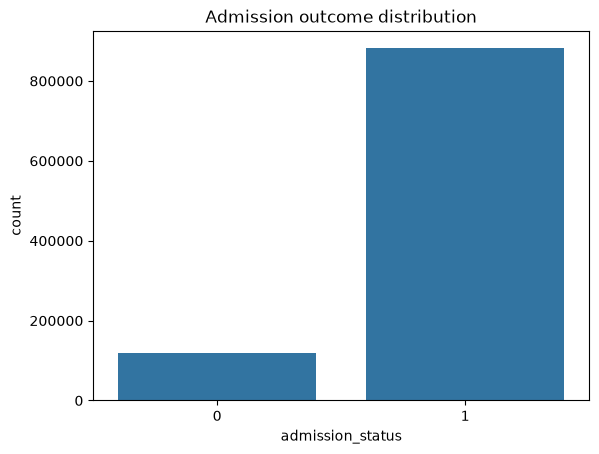

In [28]:
print(df[TARGET].value_counts())
print((df[TARGET].value_counts(normalize=True) * 100).round(2))

sns.countplot(x=TARGET, data=df)
plt.title("Admission outcome distribution")
plt.show()

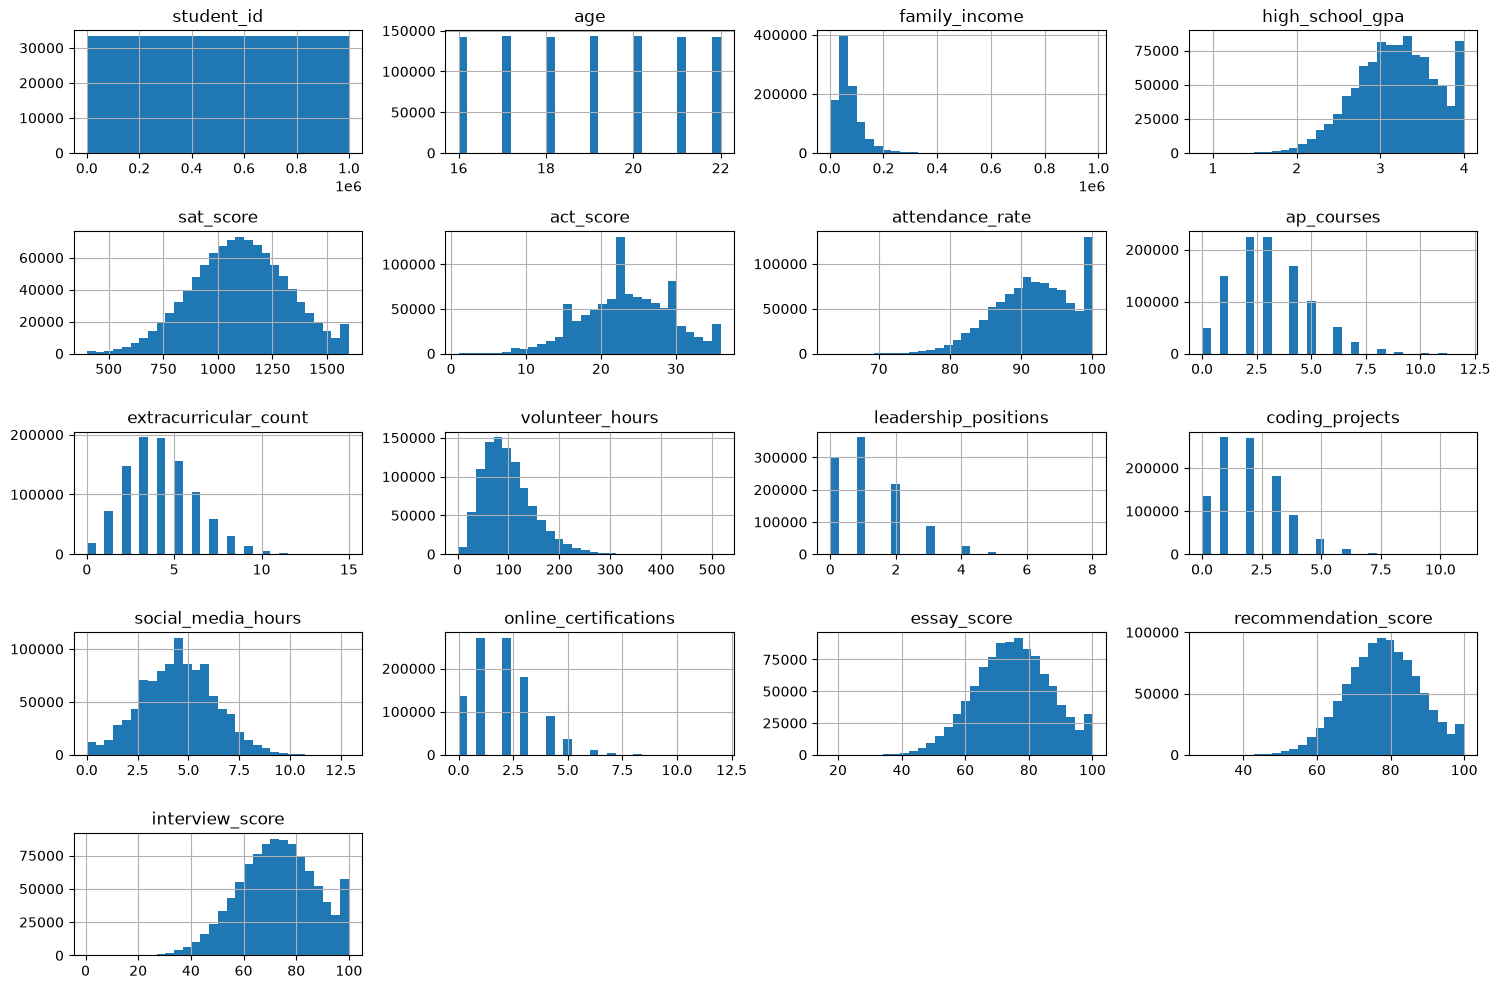

In [29]:
df[numeric_features].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

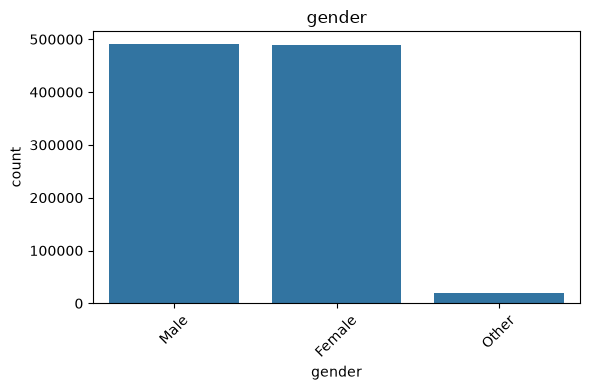

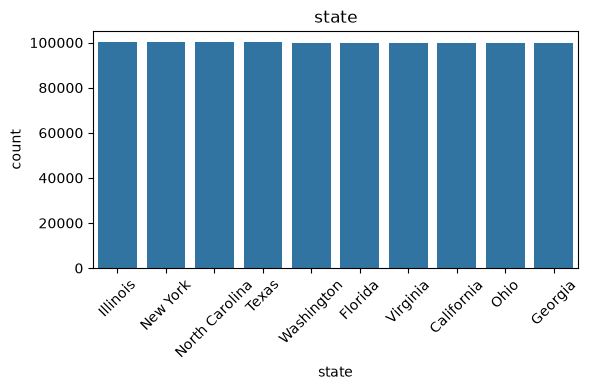

In [30]:
for col in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

features relate to admission (bivariate)

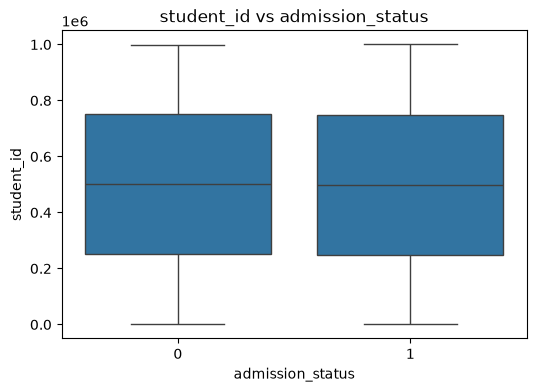

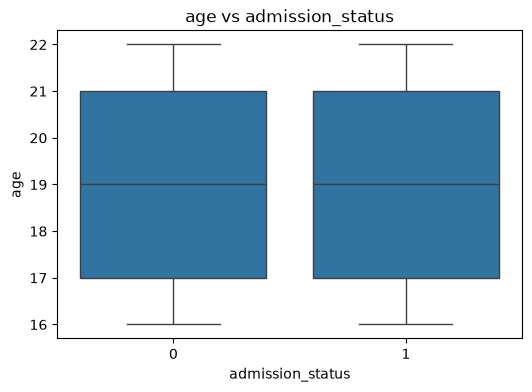

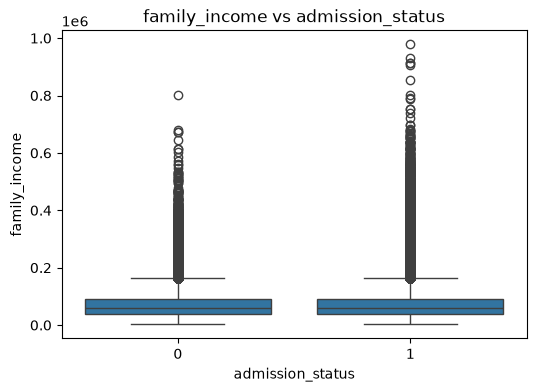

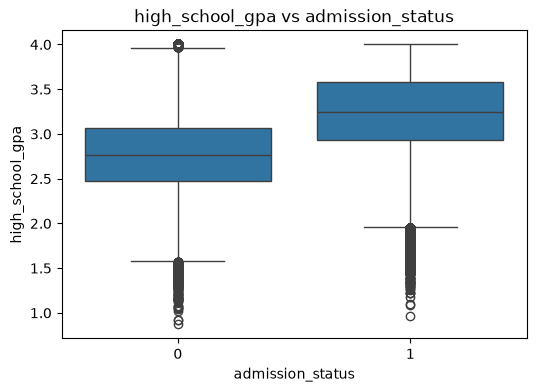

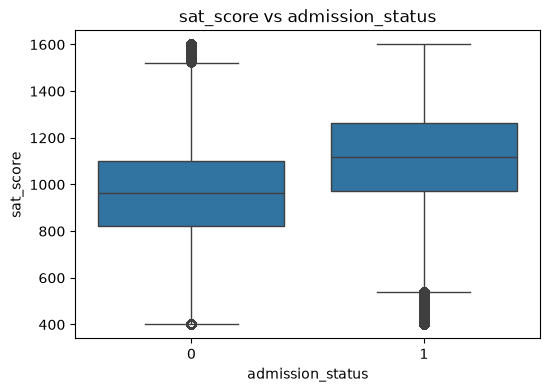

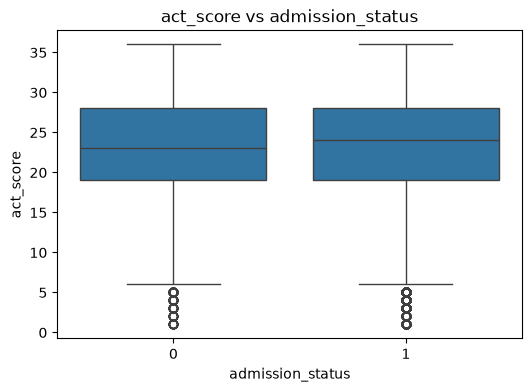

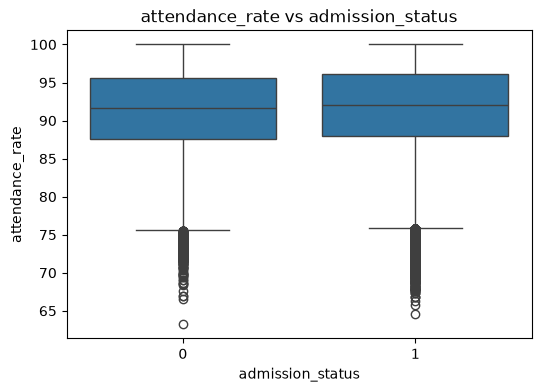

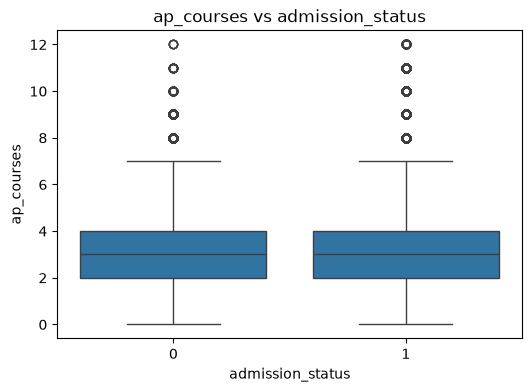

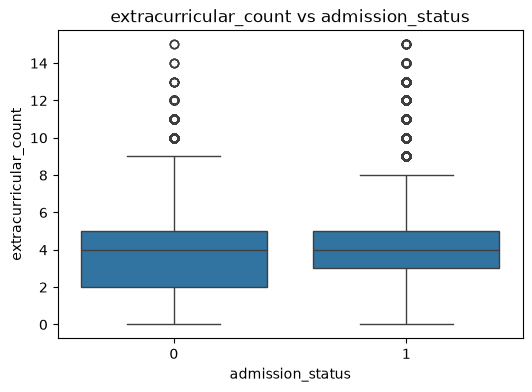

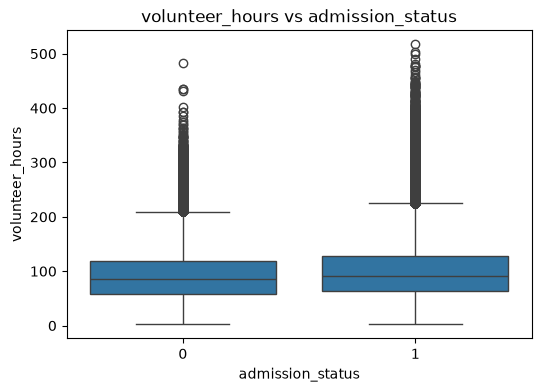

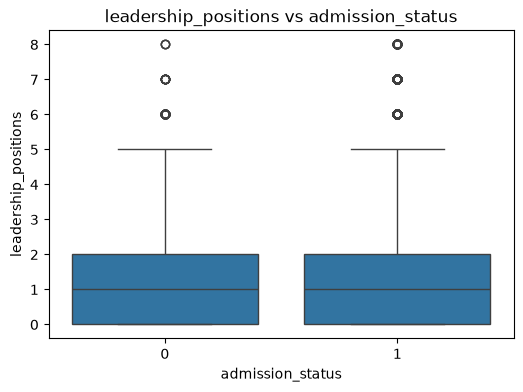

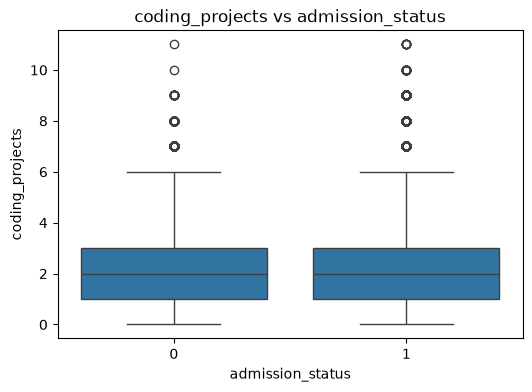

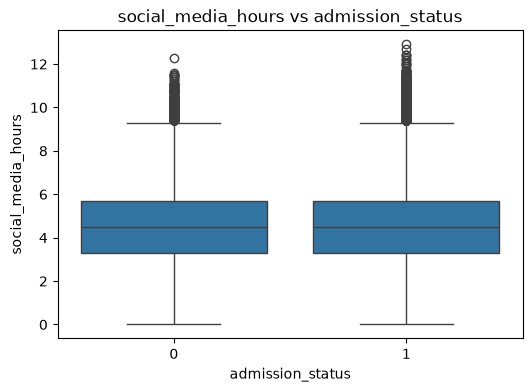

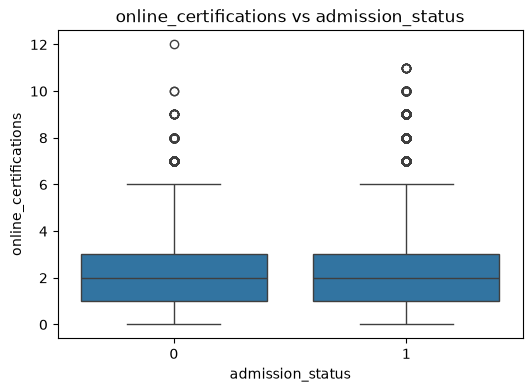

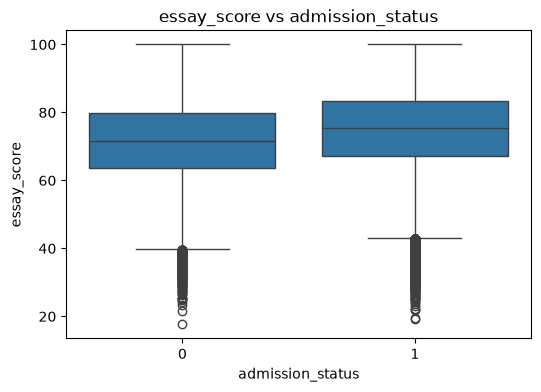

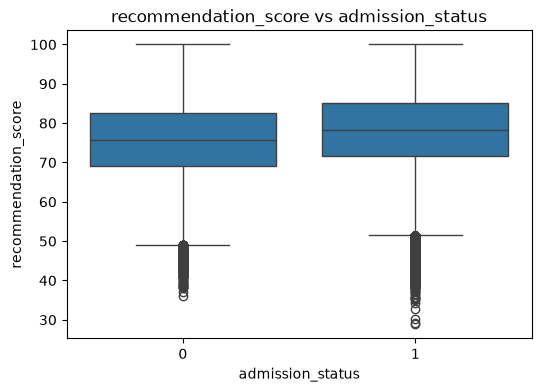

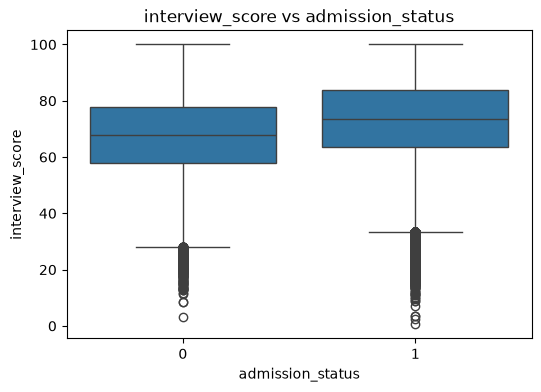

In [31]:
# numeric features split by outcome
for col in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=TARGET, y=col, data=df)
    plt.title(f"{col} vs {TARGET}")
    plt.show()

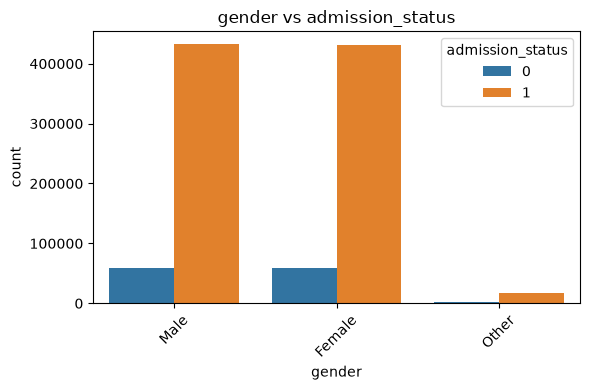

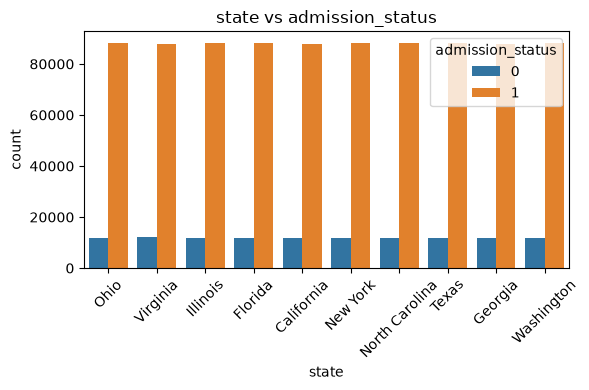

In [32]:
# categorical features split by outcome
for col in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue=TARGET, data=df)
    plt.title(f"{col} vs {TARGET}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

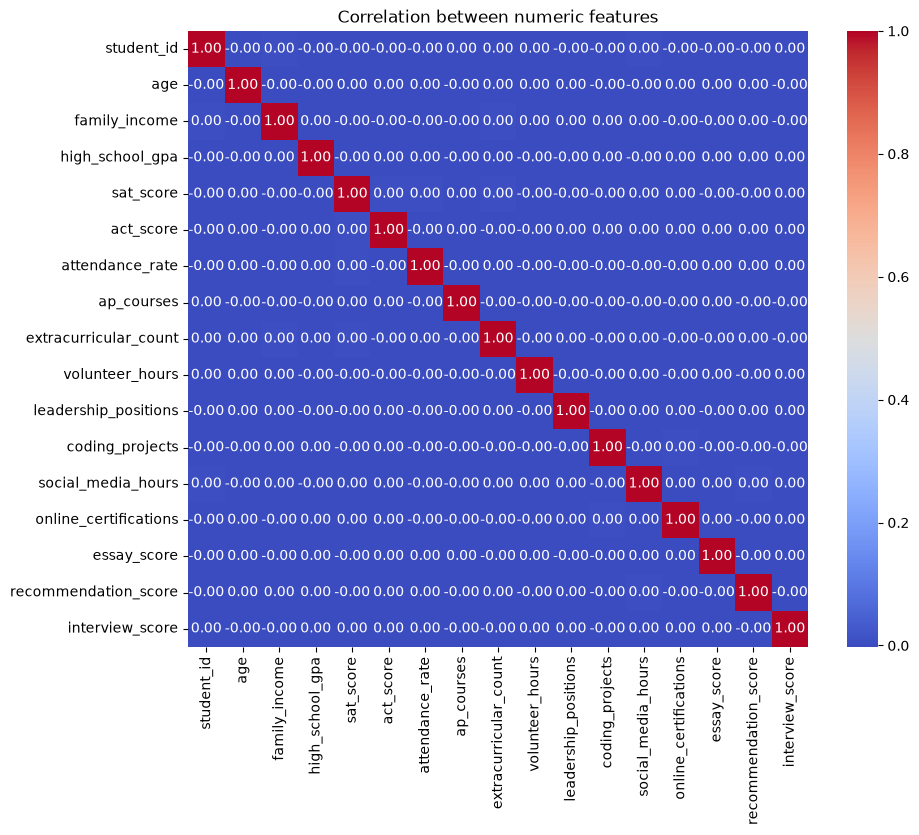

In [33]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between numeric features")
plt.show()

In [34]:
df.info()
df[TARGET].value_counts()
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   student_id             1000000 non-null  int64  
 1   age                    1000000 non-null  int64  
 2   gender                 1000000 non-null  str    
 3   state                  1000000 non-null  str    
 4   family_income          1000000 non-null  int64  
 5   high_school_gpa        1000000 non-null  float64
 6   sat_score              1000000 non-null  int64  
 7   act_score              1000000 non-null  int64  
 8   attendance_rate        1000000 non-null  float64
 9   ap_courses             1000000 non-null  int64  
 10  extracurricular_count  1000000 non-null  int64  
 11  volunteer_hours        1000000 non-null  int64  
 12  leadership_positions   1000000 non-null  int64  
 13  coding_projects        1000000 non-null  int64  
 14  social_media_hours     1000000

In [35]:
print("gender categories:", df["gender"].unique())
print("state count:", df["state"].nunique())

gender categories: <StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
state count: 10


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# stratified sample for fast iteration (full 1M is slow on a laptop)
df_sample = df.sample(n=100000, random_state=42)

DROP = ["student_id"]
num = [c for c in numeric_features if c not in DROP]
cat = categorical_features                      # ['gender', 'state']

X = df_sample.drop(columns=DROP + [TARGET])
y = df_sample[TARGET]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

for name, model in [
    ("LogisticRegression", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ("RandomForest", RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                            n_jobs=-1, random_state=42)),
]:
    pipe = Pipeline([("pre", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred  = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    print("=" * 55)
    print(name)
    print(classification_report(y_test, pred))
    print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))

LogisticRegression
              precision    recall  f1-score   support

           0       0.34      0.80      0.47      2366
           1       0.97      0.79      0.87     17634

    accuracy                           0.79     20000
   macro avg       0.65      0.79      0.67     20000
weighted avg       0.89      0.79      0.82     20000

ROC-AUC: 0.8764
RandomForest
              precision    recall  f1-score   support

           0       0.53      0.40      0.46      2366
           1       0.92      0.95      0.94     17634

    accuracy                           0.89     20000
   macro avg       0.72      0.68      0.70     20000
weighted avg       0.88      0.89      0.88     20000

ROC-AUC: 0.8644
